
# Lab 5
**Duration:** ~2 hours

**Topics:**  
- `groupby()` with `mean/sum/count`; `agg()` multi-aggregation; multi-index results  
- `pivot_table()`; merging/joining DataFrames  
- Load & explore; clean missing/inconsistent data; derive new columns  
- Use `groupby`, filtering, sorting; visualize with Pandas `.plot()`; save outputs  
- Plots: line/bar/hist/pie via `.plot()`; customize labels/titles; plot from groupby  
- Intro to `matplotlib.pyplot` (`plot`, `bar`, `scatter`); styling & basic subplots

**Instructions:** For each task, read the markdown cell and implement your solution in the empty code cell directly below it.


# Case Study: Myntra Pants Dataset — Load & Explore

**Exercise 1:** Load the dataset from `myntra_dataset_ByScraping.csv` into `df`. Show `df.shape`, `df.head(3)`, and list column names.

In [26]:
import pandas as pd
df = pd.read_csv(r"C:\Users\radha\Downloads\myntra_dataset_ByScraping.csv")
df.head()

,brand_name,pants_description,price,MRP,discount_percent,ratings,number_of_ratings
0,WROGN,Men Loose Fit Cotton Jeans,1374.0,2499.0,0.45,4.2,57.0
1,Flying Machine,Men Slim Fit Jeans,1829.0,2999.0,0.39,4.6,5.0
2,Roadster,Men Pure Cotton Jeans,974.0,2499.0,0.61,3.6,1100.0
3,Bene Kleed,Relaxed Fit Denim Jeans,873.0,2299.0,0.62,4.0,4800.0
4,Levis,Men 511 Slim Fit Jeans,1478.0,2899.0,0.49,4.3,264.0


In [27]:
df.shape

(52120, 7)

In [28]:
df.columns

Index(['brand_name', 'pants_description', 'price', 'MRP', 'discount_percent',
       'ratings', 'number_of_ratings'],
      dtype='object')

**Exercise 2:** Run `df.info()` and `df.describe(include=['number']))`. Briefly inspect possible numeric columns (price, MRP, discount_percent, ratings, number_of_ratings).

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52120 entries, 0 to 52119
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand_name         52120 non-null  object 
 1   pants_description  52120 non-null  object 
 2   price              52120 non-null  float64
 3   MRP                52120 non-null  float64
 4   discount_percent   52120 non-null  float64
 5   ratings            52120 non-null  float64
 6   number_of_ratings  52120 non-null  float64
dtypes: float64(5), object(2)
memory usage: 2.8+ MB


In [30]:
df.describe()

,price,MRP,discount_percent,ratings,number_of_ratings
count,52120.000000,52120.000000,52120.000000,52120.000000,52120.000000
mean,1594.515445,3180.398438,1.648256,3.997794,91.568937
std,1495.972325,2201.883218,4.687529,0.420404,433.918513
min,337.000000,499.000000,0.020000,1.000000,5.000000
25%,989.000000,2499.000000,0.400000,3.800000,16.000000
50%,1439.000000,2999.000000,0.500000,4.000000,35.000000
75%,1829.000000,3499.000000,0.630000,4.200000,74.000000
max,54000.000000,72000.000000,64.000000,5.000000,30700.000000


# Cleaning: Missing & Inconsistent Data

**Exercise 1:** Display total missing values per column with `df.isnull().sum()`. Identify columns with missing values.

In [31]:
 df.isnull().sum()

brand_name           0
pants_description    0
price                0
MRP                  0
discount_percent     0
ratings              0
number_of_ratings    0
dtype: int64

**Exercise 2:** Ensure numeric columns are numeric: cast `price`, `MRP`, `discount_percent`, `ratings`, `number_of_ratings` to numeric (coerce errors).

In [32]:
data = ['price', 'MRP', 'discount_percent', 'ratings', 'number_of_ratings']
for i in data:
    print(i, ":", df[i].dtype)

price : float64
MRP : float64
discount_percent : float64
ratings : float64
number_of_ratings : float64


**Exercise 3:** Handle missing numeric data: fill `ratings` with its median and `number_of_ratings` with 0. Drop rows where `price` or `MRP` is missing.

In [33]:
df['ratings'] = df['ratings'].fillna(df['ratings'].median())           # in this data we don't have any missing data thats why there is no output
df['number_of_ratings'] = df['number_of_ratings'].fillna(0)
df = df.dropna(subset=['price' , 'MRP'])

**Exercise 4:** Fix inconsistencies: ensure `price` and `MRP` are positive; clip negatives to NaN then drop. Ensure `discount_percent` is between 0 and 1 (clip), then recompute a clean `net_discount` = `(MRP - price) / MRP`.

In [34]:
import numpy as np
df.loc[df['price']<0,'price'] = np.nan                
df.loc[df['MRP']<0,'MRP'] = np.nan  # no output becz we don't have any neg. value

df = df.dropna(subset=['price' , 'MRP'])

df['net_discount'] = (df['MRP'] - df['price'])/df['MRP']

# Deriving New Columns

**Exercise 1:** Create `discount_amount = MRP - price`.

In [35]:
df['discount_amount'] = df['MRP'] - df['price']
df.head()

,brand_name,pants_description,price,MRP,discount_percent,ratings,number_of_ratings,net_discount,discount_amount
0,WROGN,Men Loose Fit Cotton Jeans,1374.0,2499.0,0.45,4.2,57.0,0.450180,1125.0
1,Flying Machine,Men Slim Fit Jeans,1829.0,2999.0,0.39,4.6,5.0,0.390130,1170.0
2,Roadster,Men Pure Cotton Jeans,974.0,2499.0,0.61,3.6,1100.0,0.610244,1525.0
3,Bene Kleed,Relaxed Fit Denim Jeans,873.0,2299.0,0.62,4.0,4800.0,0.620270,1426.0
4,Levis,Men 511 Slim Fit Jeans,1478.0,2899.0,0.49,4.3,264.0,0.490169,1421.0


**Exercise 2:** Bucket `ratings` into categories with `pd.cut`: ['low', 'mid', 'high'] using bins [0,3.5,4.2,5]. Store in `rating_band`.

In [36]:
def rating_band(rating):
    if rating <=3.5:
        return "Low"
    elif rating <=4.2:
        return "Medium"
    else:
        return "High"
df['rating_band']  = df['ratings'].apply(rating_band)
df.head()

,brand_name,pants_description,price,MRP,discount_percent,ratings,number_of_ratings,net_discount,discount_amount,rating_band
0,WROGN,Men Loose Fit Cotton Jeans,1374.0,2499.0,0.45,4.2,57.0,0.450180,1125.0,Medium
1,Flying Machine,Men Slim Fit Jeans,1829.0,2999.0,0.39,4.6,5.0,0.390130,1170.0,High
2,Roadster,Men Pure Cotton Jeans,974.0,2499.0,0.61,3.6,1100.0,0.610244,1525.0,Medium
3,Bene Kleed,Relaxed Fit Denim Jeans,873.0,2299.0,0.62,4.0,4800.0,0.620270,1426.0,Medium
4,Levis,Men 511 Slim Fit Jeans,1478.0,2899.0,0.49,4.3,264.0,0.490169,1421.0,High


# Second method

In [37]:
df['rating_category'] = pd.cut(df['ratings'],
bins = [0,3.5,4.2,5],
labels = ['Low', 'Mid', 'High'] 
                              
)
df.head()

,brand_name,pants_description,price,MRP,discount_percent,ratings,number_of_ratings,net_discount,discount_amount,rating_band,rating_category
0,WROGN,Men Loose Fit Cotton Jeans,1374.0,2499.0,0.45,4.2,57.0,0.450180,1125.0,Medium,Mid
1,Flying Machine,Men Slim Fit Jeans,1829.0,2999.0,0.39,4.6,5.0,0.390130,1170.0,High,High
2,Roadster,Men Pure Cotton Jeans,974.0,2499.0,0.61,3.6,1100.0,0.610244,1525.0,Medium,Mid
3,Bene Kleed,Relaxed Fit Denim Jeans,873.0,2299.0,0.62,4.0,4800.0,0.620270,1426.0,Medium,Mid
4,Levis,Men 511 Slim Fit Jeans,1478.0,2899.0,0.49,4.3,264.0,0.490169,1421.0,High,High


**Exercise 3:** Create `review_band` from `number_of_ratings` using `pd.qcut` into 4 quantiles (Q1..Q4).

In [38]:
df['review_band'] = pd.qcut(df['number_of_ratings'],
                            q=4,
                            labels=['Q1','Q2','Q3','Q4'])
df.head()

,brand_name,pants_description,price,MRP,discount_percent,ratings,number_of_ratings,net_discount,discount_amount,rating_band,rating_category,review_band
0,WROGN,Men Loose Fit Cotton Jeans,1374.0,2499.0,0.45,4.2,57.0,0.450180,1125.0,Medium,Mid,Q3
1,Flying Machine,Men Slim Fit Jeans,1829.0,2999.0,0.39,4.6,5.0,0.390130,1170.0,High,High,Q1
2,Roadster,Men Pure Cotton Jeans,974.0,2499.0,0.61,3.6,1100.0,0.610244,1525.0,Medium,Mid,Q4
3,Bene Kleed,Relaxed Fit Denim Jeans,873.0,2299.0,0.62,4.0,4800.0,0.620270,1426.0,Medium,Mid,Q4
4,Levis,Men 511 Slim Fit Jeans,1478.0,2899.0,0.49,4.3,264.0,0.490169,1421.0,High,High,Q4


**Exercise 4:** Create a simple `value_score = ratings * (1 + net_discount)`.

In [39]:
df['value_score'] = df['ratings'] * (1 + df['net_discount'])
df.head()

,brand_name,pants_description,price,MRP,discount_percent,ratings,number_of_ratings,net_discount,discount_amount,rating_band,rating_category,review_band,value_score
0,WROGN,Men Loose Fit Cotton Jeans,1374.0,2499.0,0.45,4.2,57.0,0.450180,1125.0,Medium,Mid,Q3,6.090756
1,Flying Machine,Men Slim Fit Jeans,1829.0,2999.0,0.39,4.6,5.0,0.390130,1170.0,High,High,Q1,6.394598
2,Roadster,Men Pure Cotton Jeans,974.0,2499.0,0.61,3.6,1100.0,0.610244,1525.0,Medium,Mid,Q4,5.796879
3,Bene Kleed,Relaxed Fit Denim Jeans,873.0,2299.0,0.62,4.0,4800.0,0.620270,1426.0,Medium,Mid,Q4,6.481079
4,Levis,Men 511 Slim Fit Jeans,1478.0,2899.0,0.49,4.3,264.0,0.490169,1421.0,High,High,Q4,6.407727


# GroupBy, Aggregations, Multi-index

**Exercise 1:** Group by `brand_name` and compute `mean price`, `mean ratings`, and `count` of products.

In [40]:
mean_price = df.groupby('brand_name')['price'].mean()
mean_ratings = df.groupby('brand_name')['ratings'].mean()
count = df.groupby('brand_name')['pants_description'].count()

# Second method

In [41]:
gb_brand = df.groupby('brand_name').agg(
     mean_price = ('price','mean'),
     mean_ratings = ('ratings','mean'),
     count = ('pants_description','count')
)
gb_brand

,mean_price,mean_ratings,count
brand_name,,,
7 For All Mankind,16223.538462,4.230769,13
7OUNCE,1329.000000,4.300000,3
AD By Arvind,1777.455285,3.993496,123
ADBUCKS,1099.000000,3.912500,8
ADIDAS Originals,6399.000000,4.100000,2
...,...,...,...
mode de base,2975.923077,4.223077,13
nostrum,1700.818182,4.009091,11
prochain,919.000000,4.150000,2


**Exercise 2:** Use `agg()` for multi-aggregation on `price` and `ratings` grouped by `brand_name` (mean, median, std).

In [42]:
gb_brand = df.groupby('brand_name').agg(
     mean_price = ('price','mean'),
     meadian_price = ('price','median'),
     std_price = ('price','std'),
     mean_rating = ('ratings','mean'),
     meadian_rating =  ('ratings','median'),
     std_rating =  ('ratings','std')
)
gb_brand

,mean_price,meadian_price,std_price,mean_rating,meadian_rating,std_rating
brand_name,,,,,,
7 For All Mankind,16223.538462,17700.0,5691.722654,4.230769,4.20,0.256205
7OUNCE,1329.000000,1349.0,62.449980,4.300000,4.30,0.000000
AD By Arvind,1777.455285,1674.0,603.750006,3.993496,4.00,0.351517
ADBUCKS,1099.000000,1099.0,106.904497,3.912500,3.80,0.285044
ADIDAS Originals,6399.000000,6399.0,6222.539674,4.100000,4.10,0.141421
...,...,...,...,...,...,...
mode de base,2975.923077,2999.0,258.694950,4.223077,4.20,0.460351
nostrum,1700.818182,1549.0,721.960223,4.009091,3.90,0.516632
prochain,919.000000,919.0,0.000000,4.150000,4.15,0.212132


**Exercise 3:** Create a **multi-index** groupby by `brand_name` and `rating_band`, aggregating `price` mean and product count. Display the first 10 rows.

In [43]:
mindex = df.groupby(['brand_name','rating_band']).agg(
    mean_price = ('price','mean'),
    product_count = ('pants_description','count')
).head(10)

mindex

mean_price  product_count
brand_name        rating_band                             
7 For All Mankind High         16309.600000              5
                  Medium       16169.750000              8
7OUNCE            High          1329.000000              3
AD By Arvind      High          1650.333333             18
                  Low           1410.571429              7
                  Medium        1827.010204             98
ADBUCKS           High           999.000000              1
                  Medium        1113.285714              7
ADIDAS Originals  Medium        6399.000000              2
AFLASH            High           824.000000              4

# Pivot Tables

**Exercise 1:** Build a pivot table with index=`brand_name`, columns=`rating_band`, values=`price`, `aggfunc='mean'`.

In [44]:
xyz = pd.pivot_table(df,
               index = 'brand_name',
               columns = 'rating_band',
               values = 'price',
               aggfunc='mean'
              )  
xyz

rating_band,High,Low,Medium
brand_name,,,
7 For All Mankind,16309.600000,NaN,16169.750000
7OUNCE,1329.000000,NaN,NaN
AD By Arvind,1650.333333,1410.571429,1827.010204
ADBUCKS,999.000000,NaN,1113.285714
ADIDAS Originals,NaN,NaN,6399.000000
...,...,...,...
mode de base,3115.666667,2799.000000,2865.666667
nostrum,1618.666667,805.000000,1864.000000
prochain,919.000000,NaN,919.000000


**Exercise 2:** Create a pivot table of product counts by `brand_name` (rows) and `review_band` (columns).

In [45]:
abc = pd.pivot_table(df,
               index = 'brand_name',
               columns = 'review_band',
               values = 'pants_description',
               aggfunc = 'count')
abc

C:\Users\radha\AppData\Local\Temp\ipykernel_6392\2252385740.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  abc = pd.pivot_table(df,


review_band,Q1,Q2,Q3,Q4
brand_name,,,,
7 For All Mankind,4,5,2,2
7OUNCE,0,0,0,3
AD By Arvind,32,31,36,24
ADBUCKS,3,2,0,3
ADIDAS Originals,1,1,0,0
...,...,...,...,...
mode de base,9,1,2,1
nostrum,3,3,1,4
prochain,0,0,1,1


# Merging / Joining DataFrames

**Exercise 1:** Create a small mapping DataFrame `brand_segment` with two segments: mark the **top 5 brands by product count** as 'Top', others as 'Other'. Merge it back to `df` on `brand_name`.

In [51]:
y = df['brand_name'].value_counts().head(5)
def create(seg):
    if seg in y:
        return "Top"
    else:
        return "Other"
brand_segment = pd.DataFrame({
    'brand_name': df['brand_name'].unique()
})    
brand_segment['segment'] = brand_segment['brand_name'].apply(create)
brand_segment


,brand_name,segment
0,WROGN,Top
1,Flying Machine,Top
2,Roadster,Top
3,Bene Kleed,Other
4,Levis,Other
...,...,...
412,IMPACKT,Other
413,Killer,Other
414,ESPRIT,Other
415,RUF & TUF,Other


In [52]:
df = df.merge(brand_segment, on='brand_name', how='left')

**Exercise 2:** Compute a summary DataFrame `seg_summary` = mean `price` and mean `ratings` by `segment`, and sort by mean price desc.

In [54]:
seg_summary = (
    df.groupby('segment')[['price', 'ratings']]
      .mean()
      .rename(columns={'price': 'mean_price', 'rating': 'mean_rating'})
      .sort_values('mean_price', ascending=False)
)
seg_summary

,mean_price,ratings
segment,,
Other,1659.119321,3.980474
Top,1494.256708,4.024672


# Filtering & Sorting

**Exercise 1:** Filter products with `value_score >= 4.0` and `net_discount >= 0.3`. Sort by `value_score` desc; show top 10.

# Visualizing with Pandas .plot() (line, bar, hist, pie); Plotting from groupby

**Exercise 1:** From `gb_brand` (mean_price/count), plot a **bar chart** of the top 10 brands by `count_items`. Add labels and title.

In [60]:
import matplotlib.pyplot as plt

In [61]:
gb_brand = (
    df.groupby('brand_name').agg(
          mean_price=('price', 'mean'),
          count_items=('brand_name', 'count')
      )
      .reset_index()
)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'WROGN'),
  Text(1, 0, 'Flying Machine'),
  Text(2, 0, 'United Colors of Benetton'),
  Text(3, 0, 'Roadster'),
  Text(4, 0, 'Mufti'),
  Text(5, 0, 'Levis'),
  Text(6, 0, 'SPYKAR'),
  Text(7, 0, 'V-Mart'),
  Text(8, 0, 'FUGAZEE'),
  Text(9, 0, 'U.S. Polo Assn. Denim Co.')])

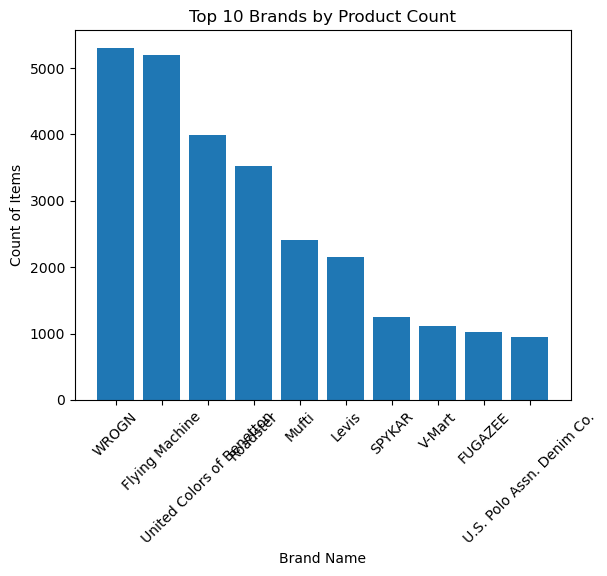

In [63]:
top_10 = gb_brand.sort_values('count_items', ascending=False).head(10)

plt.bar(top_10['brand_name'], top_10['count_items'])
plt.xlabel('Brand Name')
plt.ylabel('Count of Items')
plt.title('Top 10 Brands by Product Count')
plt.xticks(rotation=45)


**Exercise 2:** Plot a **histogram** of `net_discount` (bins=20). Label axes and add a title.

Text(0.5, 1.0, 'Distribution of Net Discount')

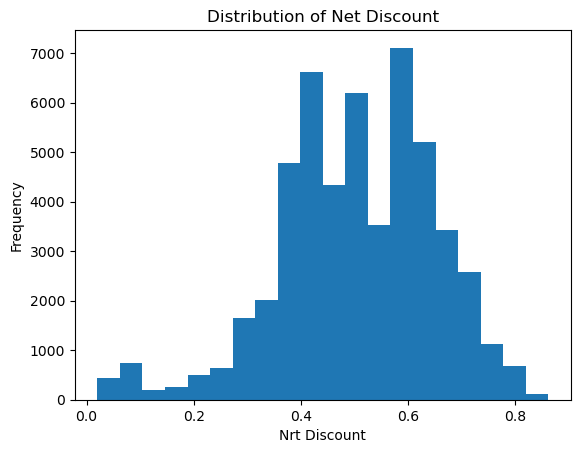

In [66]:
plt.hist(df['net_discount'], bins = 20)
plt.xlabel('Nrt Discount')
plt.ylabel('Frequency')
plt.title('Distribution of Net Discount')

**Exercise 3:** From `seg_summary`, draw a **pie chart** of `count` by `segment` with percentage labels.

Text(0.5, 1.0, 'Count by Segment')

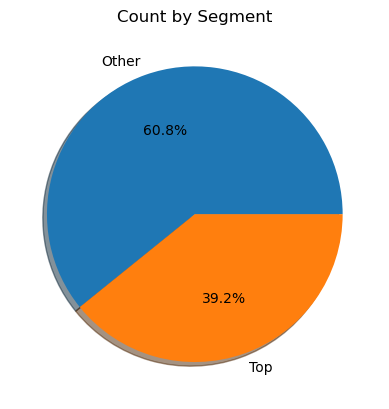

In [70]:
segment_counts = df['segment'].value_counts()
plt.pie(segment_counts, labels = segment_counts.index, autopct = '%1.1f%%',shadow = True)
plt.title('Count by Segment')

**Exercise 4:** Build a **line plot** showing mean `price` per `rating_band` (order low→mid→high).

Text(0.5, 1.0, 'Mean Price by Rating Band')

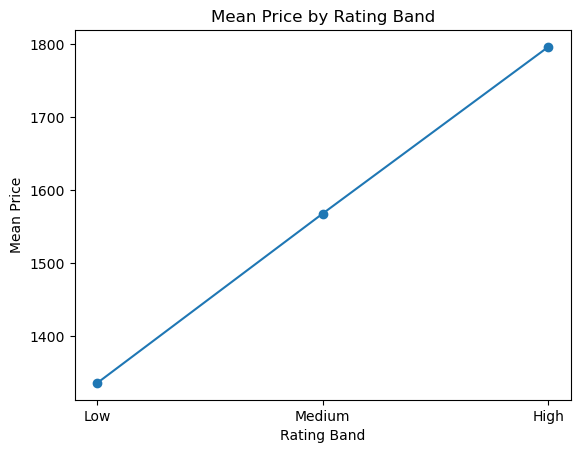

In [75]:
mean_price_band = (
    df.groupby('rating_band')['price'].mean().reindex(['Low', 'Medium', 'High'])
)

plt.plot(mean_price_band.index, mean_price_band.values, marker='o')
plt.xlabel('Rating Band')
plt.ylabel('Mean Price')
plt.title('Mean Price by Rating Band')

**Exercise 5:** Plot directly from groupby: group by `brand_name` and plot mean `ratings` (top 10 brands by count). Use a horizontal bar chart.

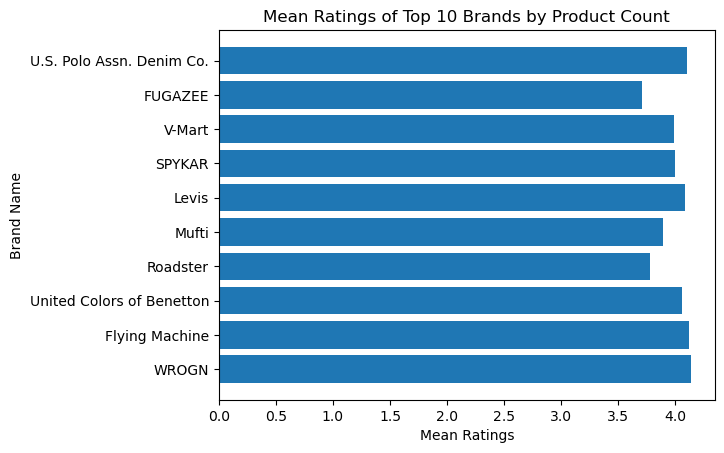

In [77]:
top_10_brands = df['brand_name'].value_counts().head(10).index

mean_ratings=(df[df['brand_name'].isin(top_10_brands)].groupby('brand_name')['ratings'].mean().loc[top_10_brands])
plt.barh(mean_ratings.index, mean_ratings.values)
plt.xlabel('Mean Ratings')
plt.ylabel('Brand Name')
plt.title('Mean Ratings of Top 10 Brands by Product Count')

# matplotlib.pyplot Basics: plot(), bar(), scatter(); Styling & Subplots

**Exercise 1:** Using matplotlib directly, create a **scatter** of `price` vs `ratings` for 500 random samples (if available). Add labels/title and alpha for visibility.

In [ ]:
import matplotlib.pyplot as plt

sample_df = df.sample(min(500, len(df)), random_state=42)

plt.scatter(sample_df['price'], sample_df['ratings'], alpha=0.5)
plt.xlabel('Price')
plt.ylabel('Ratings')
plt.title('Price vs Ratings (500 Random Samples)')

**Exercise 2:** Create a **bar chart** with matplotlib: show counts of products per `segment`.

Text(0.5, 1.0, 'Product Count by Segment')

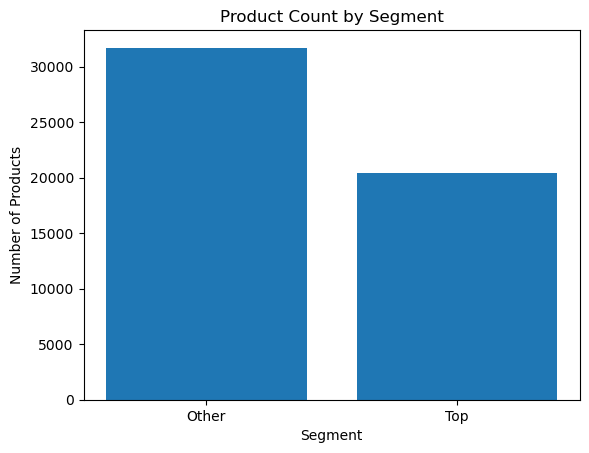

In [78]:
segment_counts = df['segment'].value_counts()

plt.bar(segment_counts.index, segment_counts.values)
plt.xlabel('Segment')
plt.ylabel('Number of Products')
plt.title('Product Count by Segment')

**Exercise 3:** Create a 1x2 **subplot** figure: (left) histogram of `ratings`; (right) histogram of `price` (use 20 bins). Add overall suptitle.

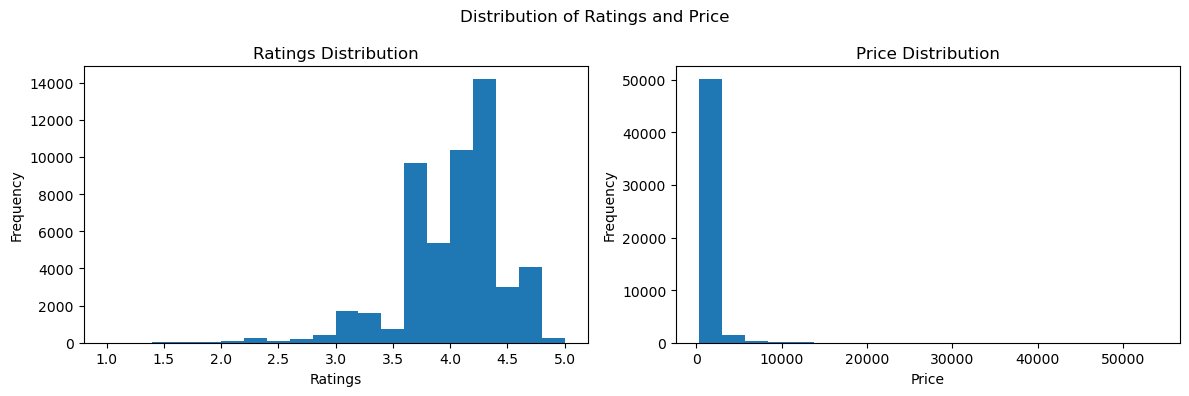

In [79]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(df['ratings'], bins=20)
ax[0].set_xlabel('Ratings')
ax[0].set_ylabel('Frequency')
ax[0].set_title('Ratings Distribution')

ax[1].hist(df['price'], bins=20)
ax[1].set_xlabel('Price')
ax[1].set_ylabel('Frequency')
ax[1].set_title('Price Distribution')

fig.suptitle('Distribution of Ratings and Price')

plt.tight_layout()
plt.show()

# Save Cleaned Data & Figures

**Exercise 1:** Save cleaned DataFrame to csv` to your local system or drive.